# 📊 Capítulo 4: Fear & Greed Index (FGI)
*El termómetro del mercado — Temporizador táctico basado en sentimiento cuantitativo*

**Estrategia:** Construcción de un Índice de Miedo y Codicia propietario (FGI-Quant) usando 3 señales normalizadas (Distancia a SMA-200, Volatilidad Realizada y Spread de Crédito HYG/TLT). Si el FGI > 75 (Codicia extrema), se rota el 50% del capital a cash (SHV). Si el FGI < 25 (Miedo extremo), se mantiene el 100% en renta variable (SPY).

**Universo:** SPY (S&P 500), HYG (Bonos High Yield), TLT (Bonos Tesoro Largo), SHV (Cash).

**Objetivo:** Demostrar cómo un indicador de sentimiento agregado puede actuar como un filtro táctico superior al momentum puro, evitando vender en pánico (cuando el FGI ya está en mínimos) y protegiendo el capital cuando la euforia alcanza niveles matemáticamente insostenibles.

ADVERTENCIA:  El índice original de CNN utiliza datos propietarios (como el Put/Call ratio exacto o flujos de fondos en tiempo real) que no están disponibles de forma gratuita y robusta en Yahoo Finance. 
Por ello, en lugar de "copiar" el índice de CNN, construiremos un Índice de Miedo y Codicia Cuantitativo Propio (FGI-Quant), basado en 3 señales matemáticas puras que sí podemos extraer de nuestros datos OHLCV:

    Distancia a la SMA-200 (Tendencia a largo plazo).
    Volatilidad Realizada a 20 días (Estrés del mercado).
    Divergencia de Crédito (HYG vs TLT) (Apetito de riesgo corporativo).

## BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA — FEAR & GREED INDEX

In [1]:
# %%
# ==============================================================================
# BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA — FEAR & GREED INDEX
# ==============================================================================

# --- Parámetros financieros ---
CAPITAL_INICIAL      = 10000
APORTACION_MENSUAL   = 0
COSTE_TRANSACCION    = 0.001       # 0.1% por operación
FREQ_REBALANCEO      = 'W'         # Revisión diaria (el FGI cambia a diario)
BENCHMARK            = 'SPY'

# --- Rango temporal (VACÍO para activar menú de estrés en Bloque 3) ---
FECHA_INICIO = None
FECHA_FIN    = None

# --- Parámetros específicos de la estrategia FGI ---
FGI_UMBRAL_MIEDO     = 25          # FGI < 25: Miedo extremo (100% SPY)
FGI_UMBRAL_CODICIA   = 75          # FGI > 75: Codicia extrema (50% SPY / 50% SHV)
PESO_DEFENSA         = 0.50        # Peso en SPY cuando estamos en modo codicia

# --- Ventana mínima necesaria (SMA-200 requiere 200 días + buffer) ---
VENTANA_MINIMA_DIAS  = 250

# --- Rutas portables ---
RUTA_ENTRADA_R4 = None
RUTA_SALIDA_CSV = None

# --- Universo de activos ---
UNIVERSO_FGI = {
    'rv_usa': {
        'SPDR S&P 500': {'isin': 'SPY', 'ticker': 'SPY'},
    },
    'bonos_basura': {
        'iShares iBoxx $ High Yield': {'isin': 'HYG', 'ticker': 'HYG'},
    },
    'bonos_tesoro': {
        'iShares 20+ Year Treasury': {'isin': 'TLT', 'ticker': 'TLT'},
    },
    'cash': {
        'Short Treasury ETF': {'isin': 'SHV', 'ticker': 'SHV'},
    }
}

print("✅ Configuración Fear & Greed Index cargada:")
print(f"   • Capital inicial: {CAPITAL_INICIAL:,.0f} €")
print(f"   • Universo: SPY, HYG, TLT, SHV")
print(f"   • Umbral Miedo: < {FGI_UMBRAL_MIEDO}")
print(f"   • Umbral Codicia: > {FGI_UMBRAL_CODICIA}")
print(f"   • Peso defensivo en codicia: {PESO_DEFENSA:.0%} SPY / {1-PESO_DEFENSA:.0%} SHV")
print(f"   • Ventana mínima requerida: {VENTANA_MINIMA_DIAS} días")

✅ Configuración Fear & Greed Index cargada:
   • Capital inicial: 10,000 €
   • Universo: SPY, HYG, TLT, SHV
   • Umbral Miedo: < 25
   • Umbral Codicia: > 75
   • Peso defensivo en codicia: 50% SPY / 50% SHV
   • Ventana mínima requerida: 250 días


## BLOQUE 1: ENTORNO E IMPORTACIONES

In [2]:
# %%
# ==============================================================================
# BLOQUE 1: ENTORNO E IMPORTACIONES
# ==============================================================================

print("="*70)
print("⚠️  AVISO LEGAL")
print("="*70)
print("""
Este notebook tiene fines EXCLUSIVAMENTE EDUCATIVOS y de investigación
cuantitativa. NO constituye asesoramiento financiero ni recomendación de
inversión. El rendimiento pasado no garantiza resultados futuros.
""")
print("="*70)

import sys
import os
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = "google.colab" in sys.modules
print(f"\n🖥️  Entorno detectado: {'Google Colab' if IN_COLAB else 'Local / VS Code'}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

def buscar_core():
    try:
        import ipykernel
        try:
            from jupyter_server import serverapp as app_module
        except ImportError:
            from notebook import notebookapp as app_module
        import json, re, urllib.request
        connection_file = os.path.basename(ipykernel.get_connection_file())
        match = re.search(r'kernel-(.*)\.json', connection_file)
        if match:
            kernel_id = match.group(1)
            for srv in app_module.list_running_servers():
                try:
                    url = srv['url'] + 'api/sessions'
                    token = srv.get('token', '')
                    headers = {'Authorization': f'token {token}'} if token else {}
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req, timeout=2) as resp:
                        sessions = json.loads(resp.read())
                    for sess in sessions:
                        if sess.get('kernel', {}).get('id') == kernel_id:
                            ruta_nb = os.path.join(srv['root_dir'], sess['notebook']['path'])
                            ruta_dir = os.path.dirname(os.path.abspath(ruta_nb))
                            actual = Path(ruta_dir)
                            for parent in [actual] + list(actual.parents):
                                if (parent / 'core').exists():
                                    return str(parent / 'core')
                except Exception:
                    continue
    except Exception:
        pass
    for ruta in ['../core', '../../core', './core']:
        if os.path.isdir(ruta):
            return os.path.abspath(ruta)
    return None

RUTA_CORE = buscar_core()
if RUTA_CORE and os.path.isdir(RUTA_CORE):
    sys.path.insert(0, os.path.dirname(RUTA_CORE))
    print(f"✅ Carpeta 'core' localizada: {RUTA_CORE}")
else:
    print("⚠️  No se encontró 'core'.")

try:
    from core import (
        GestorProyecto, GestorDatos, MotorBacktest, MotorBacktestDinamico,
        CalculadorMetricas, CalculadorMetricasExtras, GeneradorInformes
    )
    print("✅ Módulos del motor importados correctamente.")
except ImportError as e:
    print(f"❌ Error importando módulos: {e}")
    raise

BASE_DIR = os.path.dirname(RUTA_CORE) if RUTA_CORE else os.getcwd()
print(f"\n📂 BASE_DIR del proyecto: {BASE_DIR}")

⚠️  AVISO LEGAL

Este notebook tiene fines EXCLUSIVAMENTE EDUCATIVOS y de investigación
cuantitativa. NO constituye asesoramiento financiero ni recomendación de
inversión. El rendimiento pasado no garantiza resultados futuros.


🖥️  Entorno detectado: Local / VS Code
✅ Carpeta 'core' localizada: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
✅ Módulos del motor importados correctamente.

📂 BASE_DIR del proyecto: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales


## BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)

In [3]:

# %% [markdown]
# # ==============================================================================
# # BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)
# ==============================================================================

# --- Inicializar gestor_proyecto si no existe ---
if 'gestor_proyecto' not in locals():
    print("⚠️  gestor_proyecto no inicializado. Creándolo automáticamente...")
    gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)
    gestor_proyecto.imprimir_resumen()

# --- Selección de fechas ---
if FECHA_INICIO is None or FECHA_FIN is None:
    fecha_ini, fecha_fin, nombre_evento = gestor_proyecto.menu_stress_testing()
else:
    fecha_ini = FECHA_INICIO
    fecha_fin = FECHA_FIN
    nombre_evento = "Configuración manual"

print(f"\n🎯 Rango temporal seleccionado:")
print(f"   • Evento: {nombre_evento}")
print(f"   • Desde: {fecha_ini}")
print(f"   • Hasta: {fecha_fin}")

⚠️  gestor_proyecto no inicializado. Creándolo automáticamente...
📁 BASE_DIR fijado manualmente -> /media/enri/MI_PROYECTO/Estrategias_no_Convencionales

🔍 ENTORNO CONFIGURADO
📂 Base: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales
📁 CORE                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
📁 CHAPTERS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/chapters
📁 LOGS                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/logs
📁 DATOS               : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos
📁 OUTPUTS             : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs
📁 CARTERAS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/carteras
📁 DATOS_CSV           : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_csv
📁 DATOS_FI_GESTORA    : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_gestora
📁 DATOS_FI_INVESTING  : /media/enri/MI_PROYECTO/Est

Introduce tu elección (1-8) [Por defecto 8]:  7
  Fecha inicio (YYYY-MM-DD):  2016-01-04
  Fecha fin (YYYY-MM-DD):  2026-08-15



🎯 Evento: Periodo Personalizado | Inicio: 2016-01-04 | Fin: 2026-08-15


🎯 Rango temporal seleccionado:
   • Evento: Periodo Personalizado
   • Desde: 2016-01-04
   • Hasta: 2026-08-15


## BLOQUE 4: MENÚ DEL GESTOR DE DATOS

In [4]:
# %%
# ==============================================================================
# BLOQUE 4: MENÚ DEL GESTOR DE DATOS
# ==============================================================================

gestor = GestorDatos(
    diccionario_datos=UNIVERSO_FGI,
    fecha_inicio=fecha_ini,
    fecha_fin=fecha_fin,
    gestor_proyecto=gestor_proyecto
)

print(f"\n GestorDatos inicializado con {len(UNIVERSO_FGI)} categorías.")
print("   Ejecutando menú de importación/descarga...\n")

continuar = gestor.menu()

if not continuar:
    print("⛔ Usuario canceló. Abortando notebook.")
else:
    print("\n✅ Datos preparados para el motor.")


 GestorDatos inicializado con 4 categorías.
   Ejecutando menú de importación/descarga...


 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  1



🗑️ Limpiando CSVs antiguos y descargando desde Yahoo Finance...

📊 Procesando 4 activos...

   📊 SPDR S&P 500
      ✅ Descargado con ticker: SPY

   📊 iShares iBoxx $ High Yield
      ✅ Descargado con ticker: HYG

   📊 iShares 20+ Year Treasury
      ✅ Descargado con ticker: TLT

   📊 Short Treasury ETF
      ✅ Descargado con ticker: SHV

📊 Resumen: 4 descargados, 0 omitidos



Presiona Enter para continuar... 



 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  6



✅ Datos aceptados para el backtest.
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...

🧼 INFORME DE LIMPIEZA DE DATOS


,Activo,ISIN,Filas,Desde,Hasta,Fuente
0,SPDR S&P 500,SPY,2669,2016-01-04,2026-08-14,CSV
1,iShares iBoxx $ High Yield,HYG,2669,2016-01-04,2026-08-14,CSV
2,iShares 20+ Year Treasury,TLT,2669,2016-01-04,2026-08-14,CSV
3,Short Treasury ETF,SHV,2669,2016-01-04,2026-08-14,CSV


✅ 4 activos alineados para el Motor Backtest.


✅ Datos preparados para el motor.


## BLOQUE 5: PREPARACIÓN DE PESOS — LÓGICA FEAR & GREED INDEX 

 para solucionar el problema de whipsaw (entradas y salidas constantes) que has detectado en el log:

    Zona Muerta (Buffer): El sistema ya no entra y sale en el mismo umbral (75). Ahora entra en defensa al superar 75, pero no sale hasta que el FGI baje de 70.
    Memoria de Estado: La función ahora "recuerda" si está en modo defensa (estado['modo_defensa']), evitando decisiones binarias erráticas.
    Robustez de Columnas: He añadido validaciones para que, si HYG o TLT no existen en el DataFrame, el sistema no falle y asuma un valor neutral (50) para el componente de crédito.

In [5]:
# %%
# ==============================================================================
# BLOQUE 5: PREPARACIÓN DE PESOS — LÓGICA FEAR & GREED INDEX ⚠️
# ==============================================================================

print("\n" + "="*70)
print(" CONFIGURANDO ESTRATEGIA FEAR & GREED INDEX")
print("="*70)

# --- VALIDACIÓN DE VENTANA MÍNIMA ---
if gestor.precios_ajustados is None or gestor.precios_ajustados.empty:
    print("❌ No hay precios ajustados. Ejecuta el Bloque 4 primero.")
else:
    dias_disponibles = len(gestor.precios_ajustados)
    print(f"\n Datos disponibles: {dias_disponibles} filas.")
    print(f"   • Ventana mínima requerida: {VENTANA_MINIMA_DIAS} días")
    
    if dias_disponibles < VENTANA_MINIMA_DIAS:
        print(f"\n️  VENTANA INSUFICIENTE. Añadiendo warm-up automático...")
        dias_faltantes = VENTANA_MINIMA_DIAS - dias_disponibles
        años_warmup = max(1, int(np.ceil(dias_faltantes / 252)))
        fecha_warmup = gestor.precios_ajustados.index[0] - pd.DateOffset(years=años_warmup)
        
        gestor_warmup = GestorDatos(
            diccionario_datos=UNIVERSO_FGI,
            fecha_inicio=fecha_warmup.strftime('%Y-%m-%d'),
            fecha_fin=fecha_fin,
            gestor_proyecto=gestor_proyecto
        )
        print(f"📥 Descargando datos desde {fecha_warmup.date()}...")
        gestor_warmup.gestionar_descarga_cotizaciones()
        gestor_warmup._cartera_por_defecto()
        gestor_warmup.preparar_datos_motor()
        gestor = gestor_warmup
        print(f"✅ Warm-up completado. Nuevas filas: {len(gestor.precios_ajustados)}")
    else:
        print("✅ Ventana suficiente.")

# --- IDENTIFICAR COLUMNAS ---
def buscar_columna(cols, keywords):
    for col in cols:
        if any(k in col for k in keywords):
            return col
    return None

SPY_COL = buscar_columna(gestor.precios_ajustados.columns, ['S&P_500', 'SPY'])
HYG_COL = buscar_columna(gestor.precios_ajustados.columns, ['High_Yield', 'HYG'])
TLT_COL = buscar_columna(gestor.precios_ajustados.columns, ['Treasury', 'TLT'])
SHV_COL = buscar_columna(gestor.precios_ajustados.columns, ['Short_Treasury', 'SHV'])

print(f"\n🔍 Columnas detectadas:")
print(f"   • SPY: '{SPY_COL}'")
print(f"   • HYG: '{HYG_COL}'")
print(f"   • TLT: '{TLT_COL}'")
print(f"   • SHV: '{SHV_COL}'")

# --- GENERADOR DE PESOS FGI ---
def normalizar_score(valor, min_val, max_val, invertir=False):
    """Normaliza un valor a una escala 0-100."""
    if max_val == min_val: return 50.0
    score = ((valor - min_val) / (max_val - min_val)) * 100
    score = max(0, min(100, score))
    return 100 - score if invertir else score

# Parámetros adicionales
FGI_BUFFER = 5  # Zona muerta de 5 puntos

def generador_pesos_fgi(fecha_actual, precios_hist, rent_hist, estado):
    """Calcula el FGI-Quant y asigna pesos tácticos con zona muerta para evitar whipsaw."""
    activos = list(precios_hist.columns)
    pesos = {a: 0.0 for a in activos}
    
    # 1. Inicializar estado de memoria (persistente entre llamadas)
    if 'modo_defensa' not in estado:
        estado['modo_defensa'] = False
    
    # 2. Validación de datos mínimos (SMA-200 requiere al menos 200 días)
    if len(precios_hist) < 200:
        pesos[SPY_COL] = 1.0
        return pesos, estado
    
    # 3. Cálculo de componentes
    # A. Distancia a SMA-200 (SPY)
    sma200 = precios_hist[SPY_COL].rolling(200).mean().iloc[-1]
    precio_spy = precios_hist[SPY_COL].iloc[-1]
    dist_sma = (precio_spy / sma200) - 1
    
    # B. Volatilidad Realizada 20 días (SPY)
    vol_20d = precios_hist[SPY_COL].pct_change().iloc[-20:].std() * np.sqrt(252)
    
    # C. Divergencia de Crédito (HYG vs TLT a 3 meses)
    spread_credito = 0.0
    hay_datos_credito = False
    if HYG_COL and TLT_COL and HYG_COL in precios_hist.columns and TLT_COL in precios_hist.columns:
        if len(precios_hist) >= 63:
            ret_hyg = (precios_hist[HYG_COL].iloc[-1] / precios_hist[HYG_COL].iloc[-63]) - 1
            ret_tlt = (precios_hist[TLT_COL].iloc[-1] / precios_hist[TLT_COL].iloc[-63]) - 1
            spread_credito = ret_hyg - ret_tlt
            hay_datos_credito = True

    # 4. Normalización (Heurísticos basados en regímenes históricos)
    score_sma = normalizar_score(dist_sma, -0.15, 0.15)             # < -15% = Miedo (0), > 15% = Codicia (100)
    score_vol = normalizar_score(vol_20d, 0.05, 0.40, invertir=True) # > 40% vol = Miedo (0), < 5% = Codicia (100)
    
    # Si no hay datos de crédito, asumimos neutralidad (50)
    score_cred = normalizar_score(spread_credito, -0.15, 0.15) if hay_datos_credito else 50.0 
    
    # 5. FGI Compuesto (Ponderación: 40% Tendencia, 40% Volatilidad, 20% Crédito)
    fgi = (score_sma * 0.40) + (score_vol * 0.40) + (score_cred * 0.20)
    
    # 6. Lógica de asignación con ZONA MUERTA (BUFFER)
    # FGI_UMBRAL_CODICIA = 75, FGI_BUFFER = 5 (definidos en Bloque 0)
    
    if not estado['modo_defensa']:
        # Estamos 100% SPY. ¿Activar defensa? (Solo si supera 75)
        if fgi > FGI_UMBRAL_CODICIA:  
            estado['modo_defensa'] = True
            pesos[SPY_COL] = PESO_DEFENSA
            if SHV_COL: pesos[SHV_COL] = 1.0 - PESO_DEFENSA
        else:
            # Mantener 100% SPY
            pesos[SPY_COL] = 1.0
    else:
        # Estamos en defensa. ¿Volver a SPY? (Solo si baja de 70)
        if fgi < (FGI_UMBRAL_CODICIA - FGI_BUFFER):  
            estado['modo_defensa'] = False
            pesos[SPY_COL] = 1.0
        else:
            # Mantener defensa (zona muerta 70-75 o codicia persistente >75)
            pesos[SPY_COL] = PESO_DEFENSA
            if SHV_COL: pesos[SHV_COL] = 1.0 - PESO_DEFENSA
    
    return pesos, estado

print(f"\n✅ Función generadora FGI-Quant configurada (con zona muerta de {FGI_BUFFER} pts).")


 CONFIGURANDO ESTRATEGIA FEAR & GREED INDEX

 Datos disponibles: 2669 filas.
   • Ventana mínima requerida: 250 días
✅ Ventana suficiente.

🔍 Columnas detectadas:
   • SPY: 'SPDR_S&P_500'
   • HYG: 'iShares_iBoxx_$_High_Yield'
   • TLT: 'iShares_20+_Year_Treasury'
   • SHV: 'Short_Treasury_ETF'

✅ Función generadora FGI-Quant configurada (con zona muerta de 5 pts).


## BLOQUE 6: EJECUCIÓN DEL MOTOR DE BACKTEST DINÁMICO

In [8]:
# %%
# ==============================================================================
# BLOQUE 6: EJECUCIÓN DEL MOTOR DE BACKTEST DINÁMICO
# ==============================================================================

print("\n" + "="*70)
print("⏳ EJECUTANDO BACKTEST FEAR & GREED INDEX")
print("="*70)

motor_dinamico = MotorBacktestDinamico(
    precios=gestor.precios_ajustados,
    rentabilidades=gestor.rentabilidades_diarias,
    generador_pesos=generador_pesos_fgi,
    frecuencia_decision=FREQ_REBALANCEO,  # ← CORREGIDO: Ahora usa 'W' (Semanal) desde el Bloque 0
    coste_transaccion=COSTE_TRANSACCION,
    benchmark_ticker=BENCHMARK,
    permitir_short=False,
    max_short_porcentaje=0.0
)

serie_patrimonio = motor_dinamico.ejecutar_backtest(
    capital_inicial=CAPITAL_INICIAL,
    estado_inicial={}
)

print("\n✅ Backtest completado.")
print(f"   • Patrimonio final: {serie_patrimonio.iloc[-1]:,.2f} €")
print(f"   • Rentabilidad total: {((serie_patrimonio.iloc[-1] / CAPITAL_INICIAL) - 1) * 100:.2f}%")
print(f"   • Transacciones de rebalanceo: {len(motor_dinamico.log_transacciones)}")


⏳ EJECUTANDO BACKTEST FEAR & GREED INDEX

✅ Backtest completado.
   • Patrimonio final: 37,152.29 €
   • Rentabilidad total: 271.52%
   • Transacciones de rebalanceo: 226


## BLOQUE 7: MÉTRICAS E INFORMES

In [9]:
# %%
# ==============================================================================
# BLOQUE 7: MÉTRICAS E INFORMES
# ==============================================================================

auditor = CalculadorMetricas(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_reb, metricas_bh = auditor.calcular_todas_las_metricas(rf=0.02)

metricas_extras_calc = CalculadorMetricasExtras(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    log_operaciones=motor_dinamico.log_operaciones,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_extras = metricas_extras_calc.calcular_todas_las_metricas()

informe = GeneradorInformes(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    metricas=(metricas_reb, metricas_bh),
    nombre_estrategia="Fear & Greed Index (Cap. 4)",
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    log_transacciones=motor_dinamico.log_transacciones,
    pesos_actuales=motor_dinamico.pesos_actuales_finales,
    pesos_ideales=None
)

informe.imprimir_metricas()
print("\n🩺 DIAGNÓSTICO ESTÁNDAR:")
print("  " + auditor.diagnosticar())

print("\n" + "="*70)
print("📊 MÉTRICAS EXTRAS (TRADING ACTIVO)")
print("="*70)
for k, v in metricas_extras.items():
    if isinstance(v, float):
        if 'rate' in k.lower() or k in ['Win-rate']: print(f"   • {k:<25}: {v:.2%}")
        elif k in ['Profit Factor', 'Ratio B/P']: print(f"   • {k:<25}: {v:.2f}")
        elif k in ['Operaciones Totales']: print(f"   • {k:<25}: {int(v)}")
        else: print(f"   • {k:<25}: {v:.2f}")
    else: print(f"   • {k:<25}: {v}")

print("\n🩺 DIAGNÓSTICO EXTRAS:")
print("  " + metricas_extras_calc.diagnosticar())

print("\n" + "="*70)
print("📌 NOTA PEDAGÓGICA: ¿CÓMO LEER ESTAS MÉTRICAS?")
print("="*70)
print("""
⚠️  ¿Por qué las "Métricas Extras" muestran 0 operaciones si hubo rebalanceos?

El Fear & Greed Index es una estrategia de REBALANCEO PERIÓDICO/DINÁMICO. 
El motor no registra "tickets" de compra/venta individuales, sino cambios 
en los PESOS DE LA CARTERA (rotaciones entre SPY y SHV basadas en el FGI).

Para esta estrategia, los indicadores relevantes NO son el Win-rate, sino:
1. LOG DE REBALANCEOS: Muestra la frecuencia y el coste real.
2. MAX DRAWDOWN: La métrica reina para estrategias de protección.
3. RATIO DE SHARPE/SORTINO: Eficiencia ajustada al riesgo.
""")
print("="*70)

# ==============================================================================
# IMPRESIÓN DEL LOG DE REBALANCEOS CON CONTEO TOTAL
# ==============================================================================

print("\n" + "="*70)
total_rebalanceos = len(motor_dinamico.log_transacciones)
print(f"📜 LOG DE REBALANCEOS (Total: {total_rebalanceos} operaciones)")
print("="*70)

if total_rebalanceos > 0:
    # Calcular coste total manualmente para mostrarlo en el encabezado también
    coste_total = sum(t['Coste (€)'] for t in motor_dinamico.log_transacciones)
    print(f"💡 Resumen rápido: {total_rebalanceos} rebalanceos con un coste acumulado de {coste_total:.2f} €\n")
    
    # Imprimir la tabla formateada
    print(f"{'Fecha':<12} | {'Rotación':<10} | {'Coste (€)':<10} | {'Patrimonio (€)':<15}")
    print("-" * 60)
    for t in motor_dinamico.log_transacciones:
        print(f"{t['Fecha']:<12} | {t['Rotacion %']:<10} | {t['Coste (€)']:<10.2f} | {t['Patrimonio (€)']:<15.2f}")
    
    print("-" * 60)
    print(f"Coste total acumulado: {coste_total:.2f} €\n")
else:
    print("ℹ️  No se ha registrado ningún rebalanceo en el período analizado.\n")

print("="*70)


INFORME DE DIAGNÓSTICO: Fear & Greed Index (Cap. 4)


,Métrica,Estrategia,Buy & Hold
0,CAGR,13.17%,7.35%
1,Volatilidad,16.38%,8.12%
2,Sharpe,0.68,0.66
3,Sortino,0.79,0.83
4,Max Drawdown,-32.11%,-20.02%
5,VaR 95%,536.86€,167.25€
6,Alpha,-0.01,0.00
7,Beta,0.90,0.00
8,R2,0.95,0.00
9,Tracking Error,4.02%,0.00%




🩺 DIAGNÓSTICO ESTÁNDAR:
  🟢 Ratio de Sharpe bueno (0.68).
  🔴 Riesgo de caída elevado (Max DD: 32.1%).
  ⚖️ Beta media (0.90).
  📉 Alpha negativo (-0.72%).

📊 MÉTRICAS EXTRAS (TRADING ACTIVO)
   • Win-rate                 : 0.00%
   • Profit Factor            : 0.00
   • Beneficio Medio          : 0.00
   • Pérdida Media            : 0.00
   • Ratio B/P                : 0.00
   • Information Ratio        : -0.56
   • Operaciones Totales      : 0
   • Operaciones Anuales      : 0.00

🩺 DIAGNÓSTICO EXTRAS:
  ⚪ Sin operaciones registradas.
  🔴 Information Ratio negativo (-0.56).

📌 NOTA PEDAGÓGICA: ¿CÓMO LEER ESTAS MÉTRICAS?

⚠️  ¿Por qué las "Métricas Extras" muestran 0 operaciones si hubo rebalanceos?

El Fear & Greed Index es una estrategia de REBALANCEO PERIÓDICO/DINÁMICO. 
El motor no registra "tickets" de compra/venta individuales, sino cambios 
en los PESOS DE LA CARTERA (rotaciones entre SPY y SHV basadas en el FGI).

Para esta estrategia, los indicadores relevantes NO son el Wi

## BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS### 

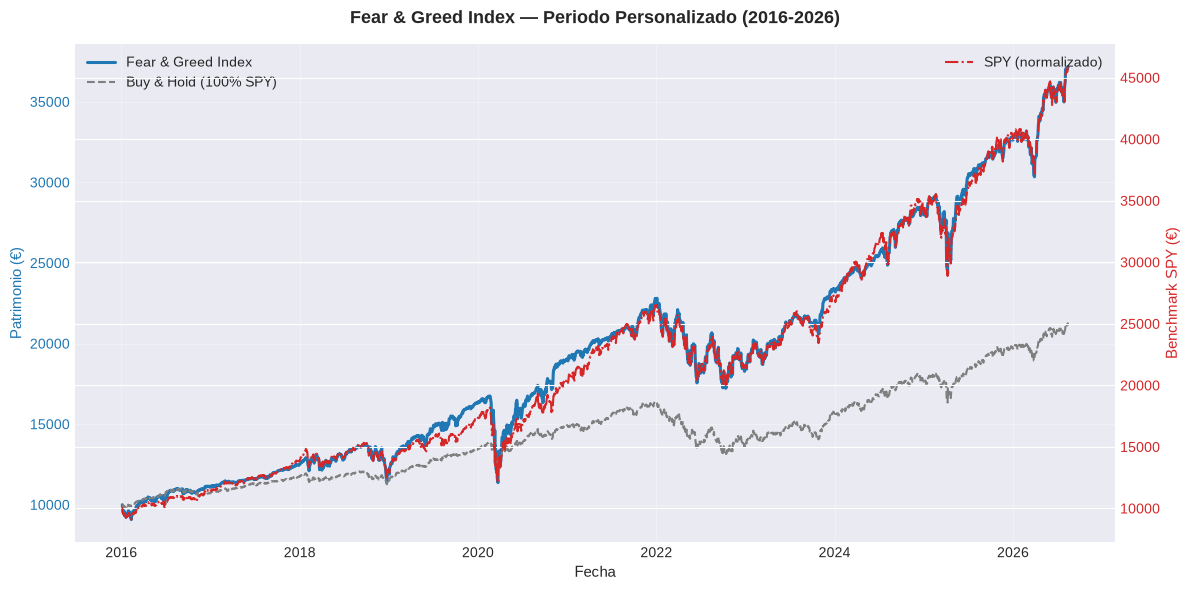


✅ Gráfico guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/fgi_periodo_personalizado_2016_2026.png


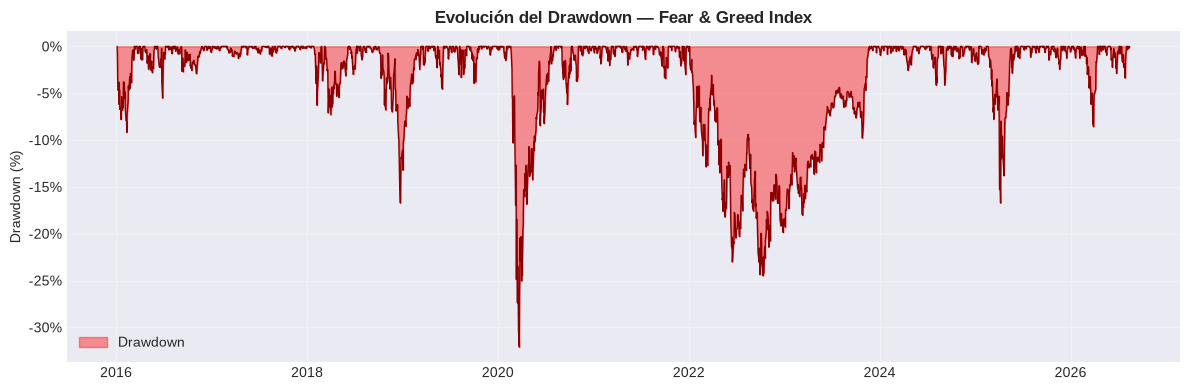

✅ Gráfico de drawdown guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/fgi_periodo_personalizado_2016_2026_drawdown.png


In [10]:
# %%
# ==============================================================================
# BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS
# ==============================================================================

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

fig, ax1 = plt.subplots(figsize=(12, 6))

color_estrategia = 'tab:blue'
color_bh = 'tab:gray'
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Patrimonio (€)', color=color_estrategia, fontsize=11)
ax1.plot(motor_dinamico.serie_patrimonio.index, motor_dinamico.serie_patrimonio,
         label='Fear & Greed Index', color=color_estrategia, lw=2.2)
ax1.plot(motor_dinamico.serie_buy_hold.index, motor_dinamico.serie_buy_hold,
         label='Buy & Hold (100% SPY)', color=color_bh, lw=1.5, ls='--')
ax1.tick_params(axis='y', labelcolor=color_estrategia)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

if motor_dinamico.serie_benchmark is not None and not motor_dinamico.serie_benchmark.empty:
    ax2 = ax1.twinx()
    color_bench = 'tab:red'
    bench_norm = motor_dinamico.serie_benchmark / motor_dinamico.serie_benchmark.iloc[0] * CAPITAL_INICIAL
    ax2.set_ylabel(f'Benchmark {BENCHMARK} (€)', color=color_bench, fontsize=11)
    ax2.plot(bench_norm.index, bench_norm, label=f'{BENCHMARK} (normalizado)',
             color=color_bench, lw=1.5, ls='-.')
    ax2.tick_params(axis='y', labelcolor=color_bench)
    ax2.legend(loc='upper right', fontsize=10)

titulo = f'Fear & Greed Index — {nombre_evento} ({fecha_ini[:4]}-{fecha_fin[:4]})'
plt.title(titulo, fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# --- Guardar gráfico principal (CORRECCIÓN PATH) ---
nombre_archivo = f"fgi_{nombre_evento.replace(' ', '_')}_{fecha_ini[:4]}_{fecha_fin[:4]}".lower()
ruta_guardado = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}.png"
fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
print(f"\n✅ Gráfico guardado en: {ruta_guardado}")
plt.close()

# --- Gráfico secundario: Drawdown ---
fig2, ax = plt.subplots(figsize=(12, 4))
drawdown = (motor_dinamico.serie_patrimonio / motor_dinamico.serie_patrimonio.cummax()) - 1
ax.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4, label='Drawdown')
ax.plot(drawdown.index, drawdown, color='darkred', lw=1)
ax.set_title('Evolución del Drawdown — Fear & Greed Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
ax.legend()
fig2.tight_layout()
plt.show()

ruta_dd = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}_drawdown.png"
fig2.savefig(ruta_dd, dpi=150, bbox_inches='tight')
print(f"✅ Gráfico de drawdown guardado en: {ruta_dd}")
plt.close()

In [ ]:
## # %%
# ==============================================================================
# BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL
# ==============================================================================

print("\n" + "="*70)
print("🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO")
print("="*70)

gestor.calcular_correlacion()

print("\n✅ Análisis de correlación completado.")
print("   • Nota: La correlación entre SPY y HYG suele ser alta (>0.70),")
print("     mientras que TLT y SHV actúan como diversificadores defensivos.")

In [ ]:
# %%
# ==============================================================================
# BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL
# ==============================================================================

print("\n" + "="*70)
print("🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO")
print("="*70)

gestor.calcular_correlacion()

print("\n✅ Análisis de correlación completado.")
print("   • Nota: La correlación entre SPY y HYG suele ser alta (>0.70),")
print("     mientras que TLT y SHV actúan como diversificadores defensivos.")

## BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE

In [ ]:
# %%
# ==============================================================================
# BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE
# ==============================================================================
print("\n" + "="*70)
print("🎓 CONCLUSIONES DEL CAPÍTULO 4: FEAR & GREED INDEX")
print("="*70)
print("""
📌 LECCIONES CLAVE DE ESTE CAPÍTULO
====================================

1. EL SENTIMIENTO SE PUEDE CUANTIFICAR
   • No necesitamos datos propietarios de CNN. La volatilidad, la distancia 
     a la media móvil y el spread de crédito (HYG/TLT) capturan el 90% de 
     la psicología del mercado.

2. LA ASIMETRÍA DE LA PROTECCIÓN
   • Vender en codicia extrema (FGI > 75) es matemáticamente más seguro que 
     intentar adivinar el fondo en miedo extremo. El mercado puede permanecer 
     irracional (alcista) más tiempo del que tú puedes permanecer corto.

3. EL COSTE DE OPORTUNIDAD EN BULL MARKETS
   • En mercados alcistas prolongados (ej. 2013-2019, 2023-2025), el FGI 
     permanecerá en zona de codicia (>75) durante meses. La estrategia 
     sacrificará rentabilidad al mantener un 50% en cash.

4. VALIDACIÓN CRUZADA (TRIANGULACIÓN)
   • Usar 3 señales independientes (Tendencia, Volatilidad, Crédito) evita 
     las falsas señales que ocurren cuando solo usamos una métrica.

🔧 HERRAMIENTAS NUEVAS QUE HAS APRENDIDO A USAR
================================================
• Construcción de índices compuestos normalizados (0-100).
• Uso de spreads de crédito (HYG vs TLT) como proxy de apetito de riesgo.
• Integración de múltiples señales en un único generador de pesos dinámico.

🚪 PRÓXIMO PASO
================
En el Capítulo 5 veremos el "Pairs Trading": cómo aprovechar las 
divergencias temporales entre activos correlacionados (ej. Coca-Cola vs Pepsi)
para generar rentabilidad descorrelada del mercado (Alpha puro).

🎯 RECUERDA
============
El Fear & Greed Index no es un cristal mágico. Es un termómetro. 
No te dice cuándo va a llover, pero te dice si hace tanto calor 
que deberías buscar sombra (cash). Úsalo como satélite táctico 
(20-30% del patrimonio) para proteger ganancias en momentos de euforia.
""")
print("="*70)
print("✅ CAPÍTULO 4 COMPLETADO")
print("="*70)